In [225]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

In [226]:
# Path definitions

BASE_DIR = Path().resolve().parent
DATA_DIR = BASE_DIR / '00_data' 


In [227]:
df_train = pd.read_csv(DATA_DIR / 'train.csv')


In [228]:
# just a test

df_eight_label = df_train.copy()

df_eight_label = df_eight_label[df_eight_label['label'] == 8].reset_index(drop=True)

df_eight_label = df_eight_label.drop(columns=['label'])

df_eight_label_analysis= pd.DataFrame(index=['zero', 'non_zero', 'nulls'], columns=df_eight_label.columns)

df_eight_label_analysis = df_eight_label_analysis.fillna(0)
df_eight_label_analysis.head()


,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
zero,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
non_zero,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
nulls,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [229]:
count_zero = 0
count_non_zero = 0
count_inv = 0
for i in range(len(df_eight_label_analysis.columns)):
   for j in range(len(df_eight_label)):
      #print(i, j)
      if df_eight_label['pixel' + str(i)][j] == 0:
         count_zero+=1
      elif (df_eight_label['pixel' + str(i)][j]) == np.nan:
         count_inv+=1
      else:
         count_non_zero+=1

   df_eight_label_analysis.loc['zero', 'pixel' + str(i)] = count_zero / len(df_eight_label)
   df_eight_label_analysis.loc['non_zero', 'pixel' + str(i)]  = count_non_zero / len(df_eight_label)
   df_eight_label_analysis.loc['nulls', 'pixel' + str(i)]  = count_inv / len(df_eight_label)
   count_zero = 0
   count_non_zero = 0
   count_inv = 0

df_eight_label_analysis = df_eight_label_analysis.transpose()


(array([ 28.,  41.,  50.,  37.,  34.,  28.,  25.,  31.,  46., 464.]),
 array([0.04233325, 0.13809993, 0.2338666 , 0.32963328, 0.42539995,
        0.52116663, 0.6169333 , 0.71269998, 0.80846665, 0.90423333,
        1.        ]),
 <BarContainer object of 10 artists>)

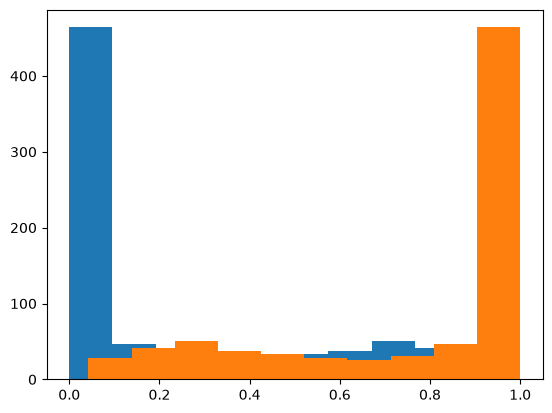

In [232]:
plt.hist(x=df_eight_label_analysis['non_zero'])
plt.hist(x=df_eight_label_analysis['zero'])